<a href="https://www.kaggle.com/code/aithbb/0-977-solution?scriptVersionId=322007168" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# NEOAI 2026: Creatures of the Static

---

# Overview

A catalog of **50 reference images** has reached us — exactly **10 per species**, 5 species in total. Then the signal arrived from elsewhere: **5000 snapshots from another dimension**, capturing the same creatures, but through a medium that distorts the image in unfamiliar ways. Your task: train on the clean catalog and correctly label every snapshot from the other side.

---

# Description

There are exactly **5 species** in the catalog. The training images came from our own world. The test snapshots, however, come from a different dimension. They carry the same creatures, but the medium they passed through has shifted them in ways the training. Knowing how exactly it differs is part of the puzzle — exploring the test set should be the first step.

---

# Data

All images are RGB, 32×32 pixels, PNG.

---

## train/ + train.csv

Clean reference images from our world, **50 total** — 10 per class.

`train.csv` columns:

- `id` — image filename inside `train/`
- `label` — integer class id `∈ {0, 1, 2, 3, 4}`

---

## test/ + test.csv

Snapshots from the other dimension, **5000 total** — 1000 per class.

`test.csv` columns:

- `id` — image filename inside `test/`

For every row, you must predict the class label.

The `test/` filenames are sequential (`00000.png … 04999.png`)

---

## sample_submission.csv

Template submission (all labels set to `0`).

Columns:

- `id` — must match `test.csv`
- `label` — predicted class id `∈ {0, 1, 2, 3, 4}`

---

# Task

For every row in `test.csv`, predict a single integer class label `∈ {0, 1, 2, 3, 4}`.

This is a **multi-class classification** problem with 5 balanced classes (1000 test samples per class).

---

# Evaluation

Submissions are evaluated using **Micro-F1 score**:

```text
F1_micro = TP_total / (TP_total + 0.5 * (FP_total + FN_total))
```

For a balanced 5-class task this is equivalent to plain accuracy. The metric is computed in two modes:

- **Public** — 50% of the test set (2500 samples), shown live during the competition,
- **Private** — the remaining 50% (2500 samples), revealed only after the deadline.

Both splits are stratified across all 5 classes.

---

# Submission File

The submission file must contain a header and follow this format:

```csv
id,label
00000.png,2
00001.png,4
00002.png,0
...
```

Exactly 5000 rows of predictions plus the header. The `id` column must match `test.csv` exactly (same filenames, same order is **not** required — the grader merges by `id`).



# NEOAI 2026: Существа Статики

---

# Обзор

До нас дошёл каталог из **50 эталонных изображений** — ровно **по 10 на каждый вид**, всего 5 видов. Затем сигнал пришёл с другой стороны: **5000 снимков из другого измерения**, на которых запечатлены те же существа, но прошедшие через среду, искажающую изображения непривычным образом. Ваша задача — обучиться на чистом каталоге и правильно определить классы всех снимков с другой стороны.

---

# Описание

В каталоге присутствует ровно **5 видов существ**. Обучающие изображения были получены в нашем мире. Тестовые снимки, однако, пришли из другого измерения. На них изображены те же существа, но среда, через которую прошёл сигнал, изменила изображения неизвестным образом. Понять, чем именно отличается тестовый набор, — часть задачи, поэтому изучение тестовых данных должно стать вашим первым шагом.

---

# Данные

Все изображения имеют формат RGB, размер 32×32 пикселя, PNG.

---

## train/ + train.csv

Чистые эталонные изображения из нашего мира, **всего 50** — по 10 на каждый класс.

Колонки `train.csv`:

- `id` — имя файла изображения внутри `train/`
- `label` — целочисленный идентификатор класса `∈ {0, 1, 2, 3, 4}`

---

## test/ + test.csv

Снимки из другого измерения, **всего 5000** — по 1000 на каждый класс.

Колонки `test.csv`:

- `id` — имя файла изображения внутри `test/`

Для каждой строки необходимо предсказать метку класса.

Файлы в `test/` имеют последовательные имена (`00000.png … 04999.png`).

---

## sample_submission.csv

Шаблон файла отправки (все метки установлены в `0`).

Колонки:

- `id` — должен совпадать с `test.csv`
- `label` — предсказанный идентификатор класса `∈ {0, 1, 2, 3, 4}`

---

# Задача

Для каждой строки в `test.csv` предскажите одно целочисленное значение класса `∈ {0, 1, 2, 3, 4}`.

Это задача **многоклассовой классификации** с 5 сбалансированными классами (по 1000 тестовых объектов на каждый класс).

---

# Оценивание

Результаты оцениваются с помощью метрики **Micro-F1 score**:

```text
F1_micro = TP_total / (TP_total + 0.5 * (FP_total + FN_total))
```

Для сбалансированной задачи на 5 классов эта метрика эквивалентна обычной accuracy. Метрика вычисляется в двух режимах:

- **Public** — 50% тестового набора (2500 объектов), отображаются на лидерборде во время соревнования,
- **Private** — оставшиеся 50% тестового набора (2500 объектов), раскрываются только после завершения соревнования.

Обе части стратифицированы по всем 5 классам.

---

# Формат отправки

Файл отправки должен содержать заголовок и соответствовать следующему формату:

```csv
id,label
00000.png,2
00001.png,4
00002.png,0
...
```

Файл должен содержать ровно 5000 строк предсказаний плюс заголовок. Колонка `id` должна полностью совпадать с `test.csv` (те же имена файлов, порядок строк **необязателен** — система сопоставляет строки по `id`).

In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
np.random.seed(42)

In [2]:
import cv2
import numpy as np
def add_random_noise(image):
    img = image.astype(np.float32).copy()
    h, w = img.shape[:2]

    border = np.concatenate([
        img[0, :, :],
        img[-1, :, :],
        img[:, 0, :],
        img[:, -1, :]
    ], axis=0)
    bg_color = np.median(border, axis=0)

    angle = np.random.uniform(0, 360)
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    img = cv2.warpAffine(
        img,
        M,
        (w, h),
        flags=cv2.INTER_NEAREST,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=tuple(float(x) for x in bg_color)
    )

    dist = np.sqrt(((img - bg_color) ** 2).sum(axis=-1))
    mask = dist > 25

    if mask.any():
        color = np.random.randint(30, 256, size=3).astype(np.float32)
        alpha = np.random.uniform(0.55, 0.9)
        img[mask] = img[mask] * (1 - alpha) + color * alpha

    img += np.random.randn(h, w, 3) * np.random.uniform(0.07, 0.16) * 255

    n_lines = np.random.randint(2, 4)
    for _ in range(n_lines):
        if np.random.rand() < 0.5:
            y = np.random.randint(0, h)
            img[y, :, :] = 255
        else:
            x = np.random.randint(0, w)
            img[:, x, :] = 255

    for _ in range(10):
        y = np.random.randint(0, h)
        x = np.random.randint(0, w)
        img[y, x] = 255

    n_rect = np.random.randint(0, 3)
    rect_color = np.random.randint(0, 256, size=3)
    for _ in range(n_rect):
        rw = np.random.randint(3, 10)
        rh = np.random.randint(3, 10)
        x1 = np.random.randint(0, max(1, w - rw + 1))
        y1 = np.random.randint(0, max(1, h - rh + 1))
        img[y1:y1+rh, x1:x1+rw] = rect_color

    return np.clip(img, 0, 255).astype(np.uint8)


def preprocess(img):
    img = img.copy()
    h, w = img.shape[:2]

    bad = (img.min(axis=-1) >= 250)

    flat = img.reshape(-1, 3)
    colors, counts = np.unique(flat, axis=0, return_counts=True)

    for color, cnt in zip(colors, counts):
        if cnt <= 15:
            continue
        if np.all(color >= 250):
            continue

        m = np.all(img == color, axis=-1).astype(np.uint8)
        num, labels, stats, _ = cv2.connectedComponentsWithStats(m, 8)

        for i in range(1, num):
            area = stats[i, cv2.CC_STAT_AREA]
            ww = stats[i, cv2.CC_STAT_WIDTH]
            hh = stats[i, cv2.CC_STAT_HEIGHT]
            if area > 15 and area >= 0.85 * ww * hh:
                bad[labels == i] = True

    bad = bad.astype(np.uint8)

    if bad.sum() > 0 and bad.sum() < h * w:
        _, nearest_labels = cv2.distanceTransformWithLabels(
            bad,
            cv2.DIST_L2,
            3,
            labelType=cv2.DIST_LABEL_PIXEL
        )
        good_coords = np.column_stack(np.where(bad == 0))
        nearest = good_coords[nearest_labels - 1]
        img[bad > 0] = img[nearest[bad > 0, 0], nearest[bad > 0, 1]]

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray = cv2.medianBlur(gray, 3)
    gray = cv2.GaussianBlur(gray, (3, 3), 0.35)

    return gray
def load_images_to_vectors(csv_file, images_folder, augment=False, n_aug=300):
    df = pd.read_csv(csv_file)
    features, labels, filenames = [], [], []

    for _, row in tqdm(df.iterrows(), total=len(df)):
        img = np.array(Image.open(os.path.join(images_folder, row['id'])).convert('RGB'))

        features.append(preprocess(img).reshape(-1))
        filenames.append(row['id'])
        if 'label' in row:
            labels.append(row['label'])

        if augment:
            for _ in range(n_aug):
                img2 = add_random_noise(img)
                features.append(preprocess(img2).reshape(-1))
                filenames.append(row['id'])
                labels.append(row['label'])

    features = np.array(features, dtype=np.float32) / 255.0

    if labels:
        return features, np.array(labels), filenames
    return features, filenames

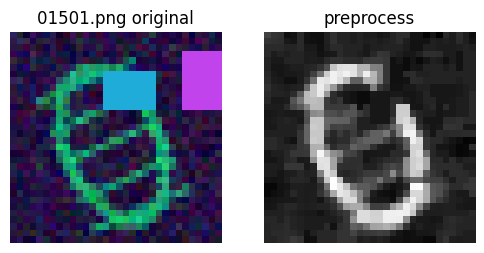

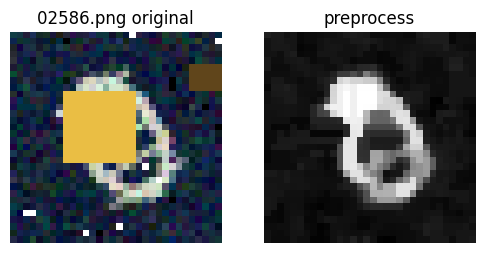

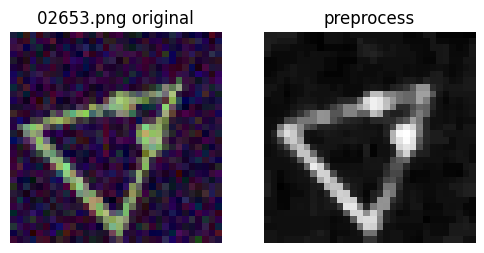

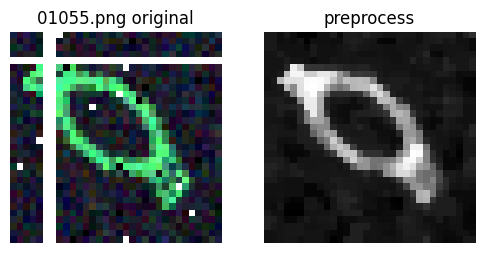

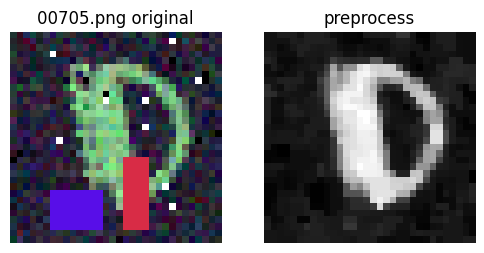

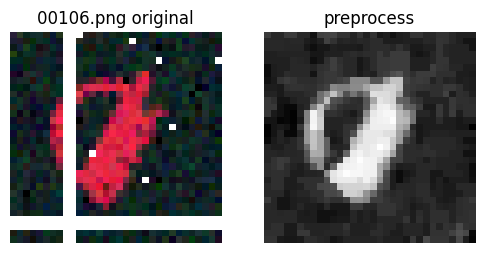

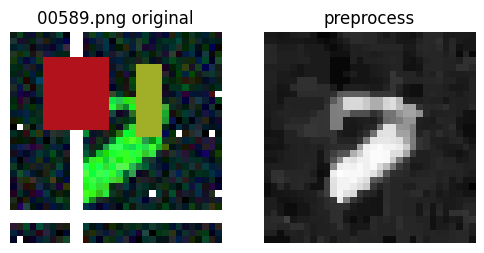

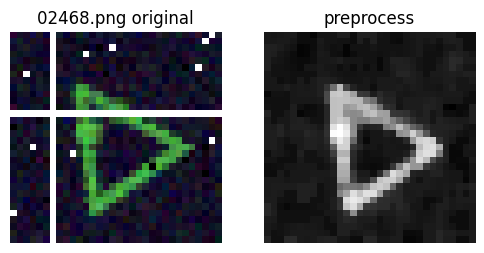

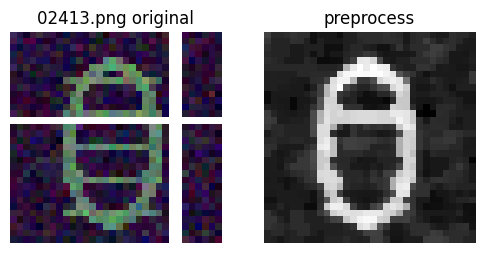

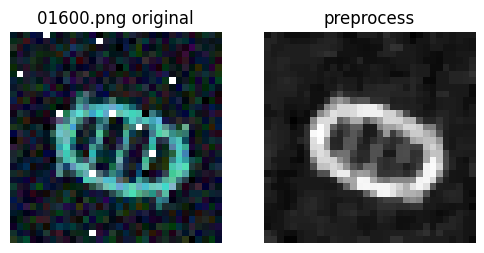

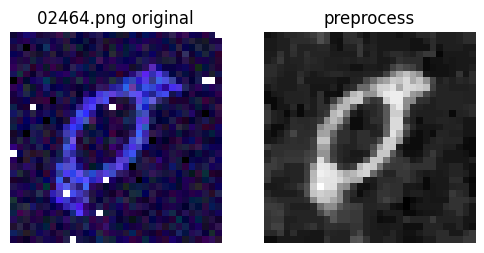

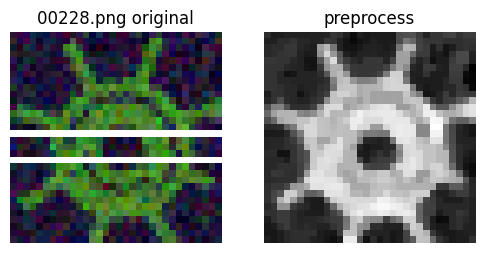

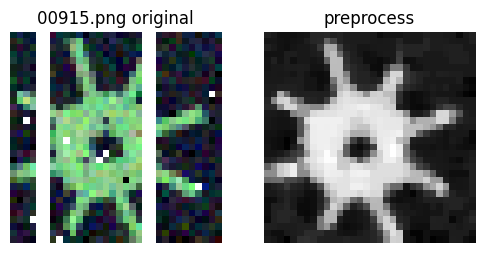

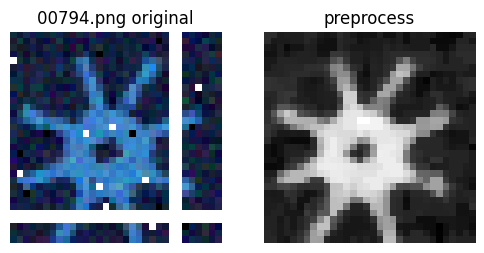

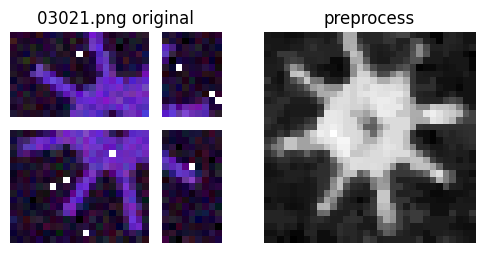

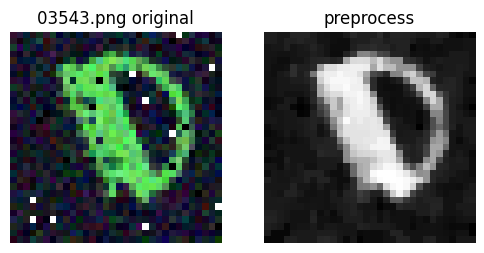

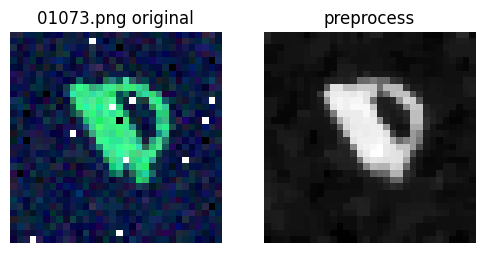

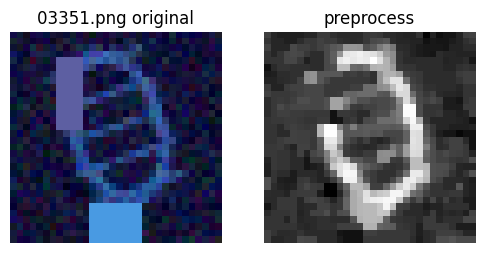

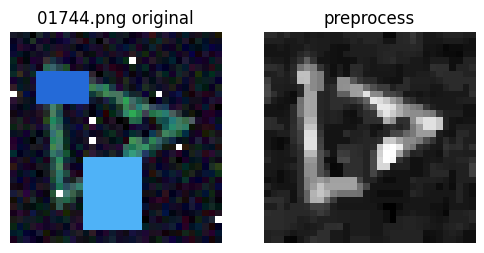

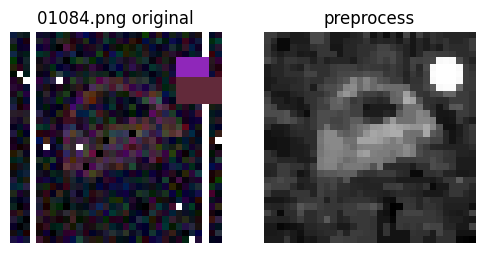

In [3]:
import matplotlib.pyplot as plt
import random

test_csv = '/kaggle/input/competitions/neoai-2026-day-2-cv/compet_data/test.csv'
test_path = '/kaggle/input/competitions/neoai-2026-day-2-cv/compet_data/test'

test_df = pd.read_csv(test_csv)
sample_rows = test_df.sample(20, random_state=42)

for _, row in sample_rows.iterrows():
    img = np.array(Image.open(os.path.join(test_path, row['id'])).convert('RGB'))
    clean = preprocess(img)

    plt.figure(figsize=(6, 3))

    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(row['id'] + ' original')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(clean, cmap='gray')
    plt.title('preprocess')
    plt.axis('off')

    plt.show()

In [4]:
X_train, y_train, _ = load_images_to_vectors(
    '/kaggle/input/competitions/neoai-2026-day-2-cv/compet_data/train.csv',
    '/kaggle/input/competitions/neoai-2026-day-2-cv/compet_data/train',
    augment=True,
    n_aug=3000
)

X_test, _ = load_images_to_vectors(
    '/kaggle/input/competitions/neoai-2026-day-2-cv/compet_data/test.csv',
    '/kaggle/input/competitions/neoai-2026-day-2-cv/compet_data/test',
    augment=False
)

print(f'train: {X_train.shape}  test: {X_test.shape}  classes: {len(np.unique(y_train))}')

100%|██████████| 5000/5000 [00:37<00:00, 135.07it/s]

train: (150050, 1024)  test: (5000, 1024)  classes: 5


In [5]:
scaler = StandardScaler()
X_train_s = X_train
X_test_s = X_test

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f'train: {X_tr.shape[0]}  val: {X_val.shape[0]}')

train: 120040  val: 30010


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

class ImgDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx], dtype=torch.float32).reshape(1, 32, 32)
        if self.y is None:
            return x
        return x, torch.tensor(self.y[idx], dtype=torch.long)

class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.c1 = nn.Conv2d(1, 16, 3, padding=1)
        self.c2 = nn.Conv2d(16, 32, 3, padding=1)
        self.c3 = nn.Conv2d(32, 64, 3, padding=1)
        self.fc1 = nn.Linear(64 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, 5)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.c1(x)), 2)
        x = F.max_pool2d(F.relu(self.c2(x)), 2)
        x = F.max_pool2d(F.relu(self.c3(x)), 2)
        x = x.reshape(x.size(0), -1)
        x = F.dropout(F.relu(self.fc1(x)), 0.3, self.training)
        return self.fc2(x)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_loader = DataLoader(ImgDataset(X_tr, y_tr), batch_size=128, shuffle=True)
val_loader = DataLoader(ImgDataset(X_val, y_val), batch_size=256, shuffle=False)

model = SmallCNN().to(device)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

best_f1 = 0
best_state = None

for epoch in range(20):
    model.train()
    loss_sum = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        opt.zero_grad()
        out = model(x)
        loss = F.cross_entropy(out, y)
        loss.backward()
        opt.step()

        loss_sum += loss.item()

    model.eval()
    preds, true = [], []
    with torch.no_grad():
        for x, y in val_loader:
            x = x.to(device)
            out = model(x)
            preds.extend(out.argmax(1).cpu().numpy())
            true.extend(y.numpy())

    val_f1 = f1_score(true, preds, average='micro')
    print(epoch, loss_sum / len(train_loader), val_f1)

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)
test_loader = DataLoader(ImgDataset(X_test), batch_size=256, shuffle=False)

test_predictions = []

model.eval()
with torch.no_grad():
    for x in test_loader:
        x = x.to(device)
        out = model(x)
        test_predictions.extend(out.argmax(1).cpu().numpy())

test_df = pd.read_csv('/kaggle/input/competitions/neoai-2026-day-2-cv/compet_data/test.csv')
test_df['label'] = test_predictions
test_df.to_csv('submission.csv', index=False)

0 0.36265746090235484 0.9681772742419194
1 0.10600878383868984 0.9801732755748084
2 0.06433435914112624 0.9881372875708098
3 0.044747001524748545 0.9917027657447518
4 0.032741209131050934 0.9931022992335888
5 0.025058226347198464 0.9940353215594802
6 0.01963631813100086 0.994168610463179
7 0.01487422309493073 0.9958013995334888
8 0.013269022704412188 0.9965678107297568
9 0.011124143787464045 0.9955348217260913
10 0.009438695877551601 0.9956347884038653
11 0.00922640609309022 0.9966677774075309
12 0.0074576280229323106 0.9957680773075641
13 0.006756204745444483 0.996967677440853
14 0.005025369769781598 0.9968343885371543
15 0.004636242649397195 0.9962012662445852
16 0.0049463769260336575 0.9969010329890037
17 0.004499896438345196 0.995134955014995
18 0.004155758696688528 0.9965678107297568
19 0.004497980789383987 0.9970676441186271


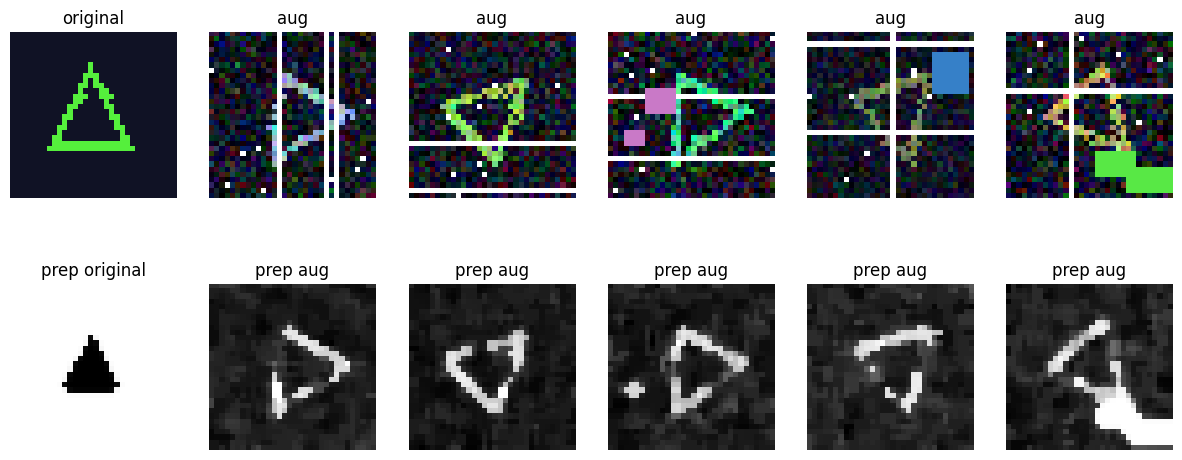

00012.png 1


In [7]:
import matplotlib.pyplot as plt
import random

train_csv = '/kaggle/input/competitions/neoai-2026-day-2-cv/compet_data/train.csv'
train_path = '/kaggle/input/competitions/neoai-2026-day-2-cv/compet_data/train'

train_df = pd.read_csv(train_csv)
row = train_df.sample(1, random_state=None).iloc[0]

img = np.array(Image.open(os.path.join(train_path, row['id'])).convert('RGB'))

plt.figure(figsize=(15, 6))

plt.subplot(2, 6, 1)
plt.imshow(img)
plt.title('original')
plt.axis('off')

plt.subplot(2, 6, 7)
plt.imshow(preprocess(img), cmap='gray')
plt.title('prep original')
plt.axis('off')

for i in range(5):
    aug = add_random_noise(img)
    prep = preprocess(aug)

    plt.subplot(2, 6, i + 2)
    plt.imshow(aug)
    plt.title('aug')
    plt.axis('off')

    plt.subplot(2, 6, i + 8)
    plt.imshow(prep, cmap='gray')
    plt.title('prep aug')
    plt.axis('off')

plt.show()

print(row['id'], row['label'])